# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Anthony Sena Fiadzo
**Student ID:** 54762028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

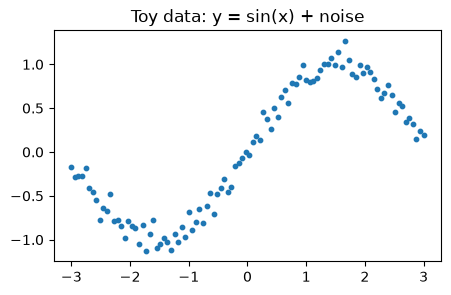

Final w=0.3360, b=0.0050, final loss=0.1892


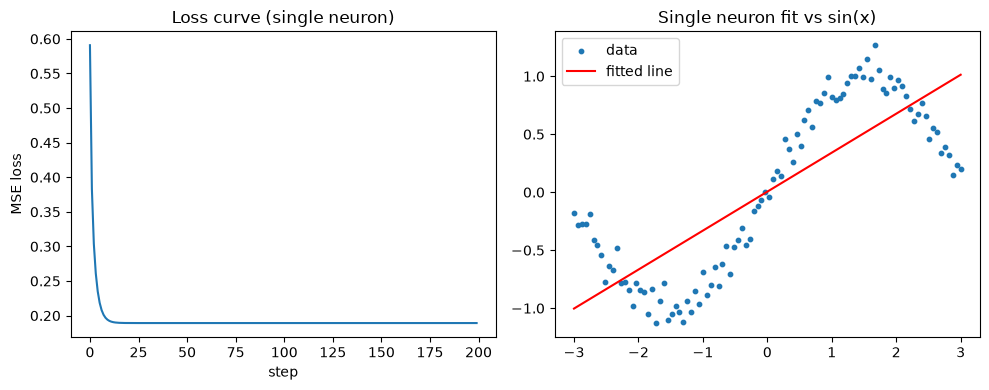

In [18]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(5, 3))
plt.scatter(x, y, s=10)
plt.title("Toy data: y = sin(x) + noise")
plt.show()

# Initialise w and b to small random values
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5

# Manual gradient descent, ~200 steps
lr = 0.1
steps = 200
losses_1_1 = []
for i in range(steps):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    losses_1_1.append(loss)

print(f"Final w={w:.4f}, b={b:.4f}, final loss={losses_1_1[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses_1_1)
axes[0].set_title("Loss curve (single neuron)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE loss")
axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, w * x + b, color="red", label="fitted line")
axes[1].set_title("Single neuron fit vs sin(x)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 
> 

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss (tanh MLP): 0.0139
Final loss (no activation / linear stack): 0.1892


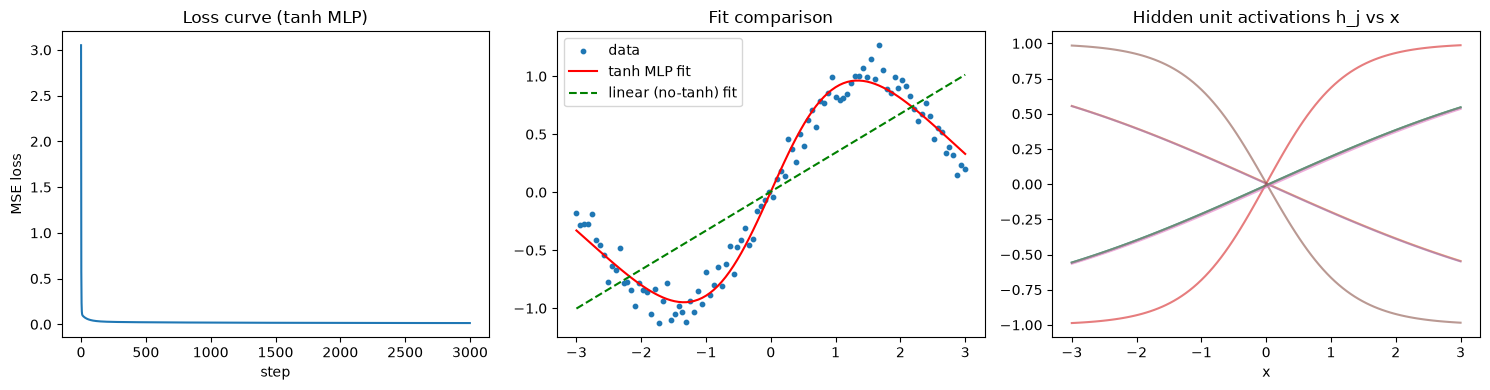

In [26]:
# Initialise parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5   # (1, 8)
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5   # (8, 1)
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)
lr = 0.05
steps = 3000
losses_1_2 = []

for i in range(steps):
    # Forward pass
    z1 = x_col @ W1 + b1        # pre-activation, (100, 8)
    h  = np.tanh(z1)             # activation
    y_hat = h @ W2 + b2          # output, (100, 1)
    loss  = np.mean((y_hat - y_col) ** 2)
    losses_1_2.append(loss)

    # Backward pass (chain rule, layer by layer)
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

print(f"Final loss (tanh MLP): {losses_1_2[-1]:.4f}")

# Re-run with tanh REMOVED (h = z1) for comparison
np.random.seed(RANDOM_STATE)
W1n = np.random.randn(1, 8) * 0.5
b1n = np.zeros(8)
W2n = np.random.randn(8, 1) * 0.5
b2n = np.zeros(1)
losses_1_2_linear = []

for i in range(steps):
    z1 = x_col @ W1n + b1n
    h  = z1                       # NO activation
    y_hat = h @ W2n + b2n
    loss = np.mean((y_hat - y_col) ** 2)
    losses_1_2_linear.append(loss)

    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2n.T
    dz1 = dh                      # derivative of identity is 1
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    W2n -= lr * dW2; b2n -= lr * db2
    W1n -= lr * dW1; b1n -= lr * db1

print(f"Final loss (no activation / linear stack): {losses_1_2_linear[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(losses_1_2)
axes[0].set_title("Loss curve (tanh MLP)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE loss")

axes[1].scatter(x, y, s=10, label="data")
z1_final = x_col @ W1 + b1
h_final = np.tanh(z1_final)
y_hat_final = h_final @ W2 + b2
axes[1].plot(x, y_hat_final, color="red", label="tanh MLP fit")
axes[1].plot(x, (x_col @ W1n + b1n) @ W2n + b2n, color="green", linestyle="--", label="linear (no-tanh) fit")
axes[1].legend()
axes[1].set_title("Fit comparison")

for j in range(8):
    axes[2].plot(x, h_final[:, j], alpha=0.6)
axes[2].set_title("Hidden unit activations h_j vs x")
axes[2].set_xlabel("x")

plt.tight_layout()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** [Double-click to edit]

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

lr=0.001: final loss = 0.052282
lr=0.05: final loss = 0.013876
lr=1.0: DIVERGED (NaN)


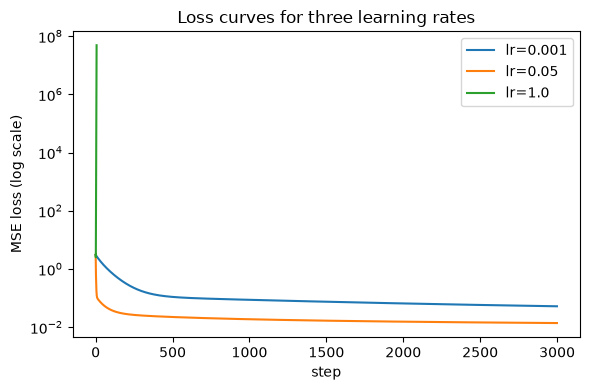

In [33]:
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)
    losses = []
    for i in range(steps):
        z1 = x_col @ W1 + b1
        h  = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)
        if not np.isfinite(loss) or loss > 1e6:
            # blown up -- stop early, pad with NaN so the plot still has the right length
            losses.extend([np.nan] * (steps - len(losses)))
            break
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
    return losses

lrs = [0.001, 0.05, 1.0]
plt.figure(figsize=(6, 4))
for l in lrs:
    losses = train_toy(l)
    print(f"lr={l}: final loss = {losses[-1]:.6f}" if np.isfinite(losses[-1]) else f"lr={l}: DIVERGED (NaN)")
    plt.plot(losses, label=f"lr={l}")
plt.yscale("log")
plt.legend()
plt.title("Loss curves for three learning rates")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.tight_layout()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

OBESITY_URL = "Obesity_level_prediction_dataset.csv"
df = pd.read_csv(OBESITY_URL)# same dataset as Lab 2

# Binary yes/no -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for c in binary_cols:
    df[c] = df[c].map({"yes": 1, "no": 0})

# Gender -> 0/1
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# CAEC / CALC are ORDINAL frequency categories (no/Sometimes/Frequently/Always) -> ordinal encode
freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df["CAEC"] = df["CAEC"].map(freq_map)
df["CALC"] = df["CALC"].map(freq_map)

# MTRANS is NOMINAL (mode of transport has no order) -> one-hot encode
df = pd.get_dummies(df, columns=["MTRANS"], drop_first=True)

# Encode target NObeyesdad into integers 0..6 -- CrossEntropyLoss expects class indices
le = LabelEncoder()
df["NObeyesdad_enc"] = le.fit_transform(df["NObeyesdad"])
class_names = le.classes_
print("Classes:", list(class_names))

y = df["NObeyesdad_enc"].values
X = df.drop(columns=["NObeyesdad", "NObeyesdad_enc"]).values.astype(float)
print("Feature count:", X.shape[1])

# Stratified 60/20/20 train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

# Fit StandardScaler on TRAINING set only; transform all three splits
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

def to_loader(Xs, ys, batch_size=32, shuffle=False):
    Xt = torch.tensor(Xs, dtype=torch.float32)
    yt = torch.tensor(ys, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train_s, y_train, batch_size=32, shuffle=True)
val_loader   = to_loader(X_val_s, y_val, batch_size=32, shuffle=False)
test_loader  = to_loader(X_test_s, y_test, batch_size=32, shuffle=False)

print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
Feature count: 19
Split sizes: train=1266, val=422, test=423


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [50]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))   # raw logits, NO softmax
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_s.shape[1]
n_classes = len(class_names)

model = FeedForwardNet(input_dim, hidden_sizes=(64, 32), n_classes=n_classes).to(DEVICE)
print(model)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
by_hand = input_dim * 64 + 64 + 64 * 32 + 32 + 32 * n_classes + n_classes
print(f"Trainable params (PyTorch count): {n_params}")
print(f"By-hand count (layer 1 = input_dim*64 + 64, etc.): {by_hand}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable params (PyTorch count): 3591
By-hand count (layer 1 = input_dim*64 + 64, etc.): 3591


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
>  **1.** With `input_dim=19` features and hidden sizes `(64, 32)` over 7 classes: Layer 1 = `19*64 + 64 = 1280`; Layer 2 = `64*32 + 32 = 2080`; Layer 3 (output) = `32*7 + 7 = 231`. Total = `1280 + 2080 + 231 = 3591`, which matches the `n_params` printed by PyTorch above exactly.
>
> **2.** `tanh` saturates (its gradient goes to ~0) for large positive or negative inputs, so gradients can vanish in deeper networks. `ReLU`'s gradient is exactly 1 for any positive input, no matter how large, so gradients flow through active units without shrinking — this makes deeper networks train faster and more reliably (it's also cheaper to compute: just `max(0, z)`).
>
> **3.** Removing the ReLUs turns the network into a stack of purely linear layers, which — exactly as proven algebraically in Part 1.2 — collapses into a single linear transformation. The whole three-layer network would compute nothing more than one big linear map from the 19 input features straight to 7 output logits, equivalent to multinomial logistic regression.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

epoch  0: train_loss=1.7807 val_loss=1.7999 train_acc=0.3744 val_acc=0.3673
epoch 10: train_loss=0.3313 val_loss=0.5340 train_acc=0.9060 val_acc=0.8483
epoch 20: train_loss=0.1398 val_loss=0.4172 train_acc=0.9731 val_acc=0.8791
epoch 30: train_loss=0.0703 val_loss=0.4515 train_acc=0.9921 val_acc=0.9052
epoch 40: train_loss=0.0332 val_loss=0.4834 train_acc=1.0000 val_acc=0.9076
epoch 49: train_loss=0.0194 val_loss=0.5175 train_acc=1.0000 val_acc=0.9123

Training time: 3.31s | best val accuracy: 0.9147


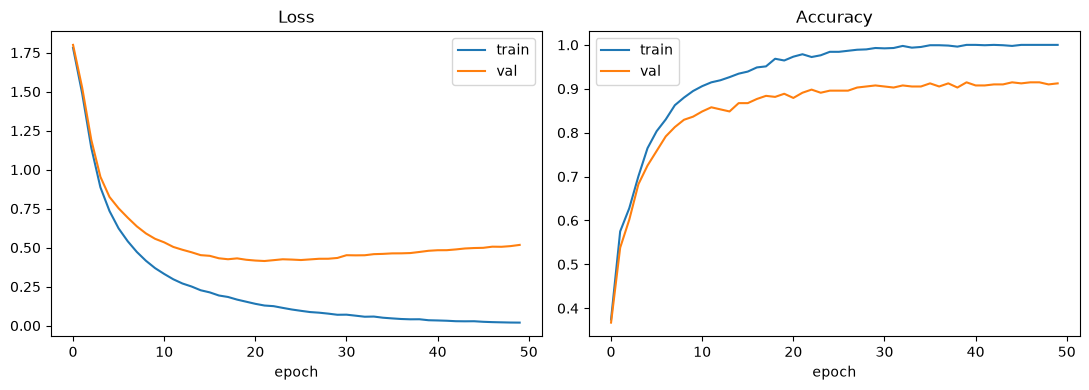

In [54]:
import time

criterion = nn.CrossEntropyLoss()
# Adam adapts the learning rate per-parameter using running gradient moment estimates,
# which converges faster and more robustly than plain SGD on this kind of tabular MLP.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(m, Xs, ys):
    m.eval()
    with torch.no_grad():
        Xt = torch.tensor(Xs, dtype=torch.float32).to(DEVICE)
        yt = torch.tensor(ys, dtype=torch.long).to(DEVICE)
        logits = m(Xt)
        loss = criterion(logits, yt).item()
        preds = logits.argmax(dim=1)
        acc = (preds == yt).float().mean().item()
    return loss, acc

epochs = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = -1
best_state = None
t0 = time.time()

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
        optimizer.step()         # <- the update rule you wrote in Part 1.1

    tr_loss, tr_acc = evaluate(model, X_train_s, y_train)
    va_loss, va_acc = evaluate(model, X_val_s, y_val)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:2d}: train_loss={tr_loss:.4f} val_loss={va_loss:.4f} "
              f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}")

train_time_main = time.time() - t0
torch.save(best_state, "ffn_best.pt")
print(f"\nTraining time: {train_time_main:.2f}s | best val accuracy: {best_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [55]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [56]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.